# Archetypal Analysis

## Introduction

In this vignette, we present

1) a brief overview of the theory behind archetypal analysis
2) a description of the optimization procedure used in our implementation
3) a guide to using the `AA` class and its `AA.fit()` method

First, we will import some package that we need throughout this vignette.

In [1]:
import partipy as pt
import numpy as np
import pandas as pd
import plotnine as pn
import matplotlib.pyplot as plt

plt.style.use("dark_background") # only for development purposes

Now, we simulate a dataset to provide an intuitive explanation of archetypal analysis. To make the simulation more realistic, we add noise to each data point by sampling a noise vector from an isotropic Gaussian distribution.

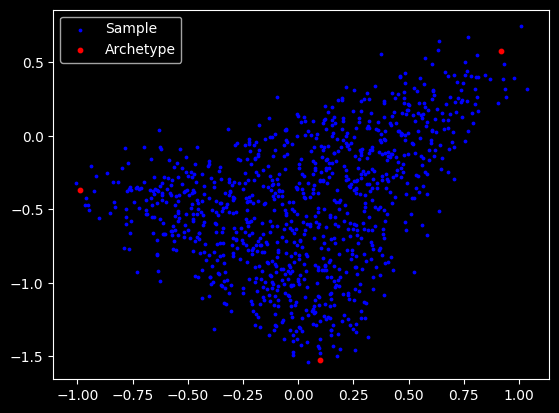

In [2]:
X, A, Z = pt.simulate_archetypes(n_samples=1_000, n_archetypes=3, n_dimensions=2, 
                                 noise_std=0.10, seed=123)

plt.scatter(x=X[:, 0], y=X[:, 1], s=3, c="blue", label="Sample")
plt.scatter(x=Z[:, 0], y=Z[:, 1], s=10, c="red", label="Archetype")
plt.legend()
plt.show()

To recover the archetypes we simply need to call

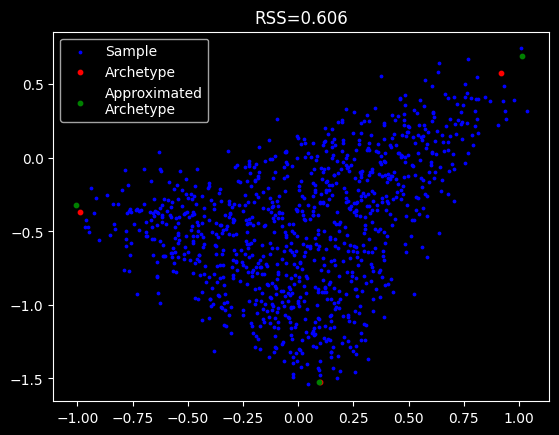

In [3]:
AA_object = pt.AA(n_archetypes=3)
AA_object.fit(X)
Z_hat = AA_object.Z

plt.scatter(x=X[:, 0], y=X[:, 1], s=3, c="blue", label="Sample")
plt.scatter(x=Z[:, 0], y=Z[:, 1], s=10, c="red", label="Archetype")
plt.scatter(x=Z_hat[:, 0], y=Z_hat[:, 1], s=10, c="green", label="Approximated\nArchetype")
plt.title(f"RSS={AA_object.RSS:.3f}")
plt.legend()
plt.show()

Relaxation of the constraint

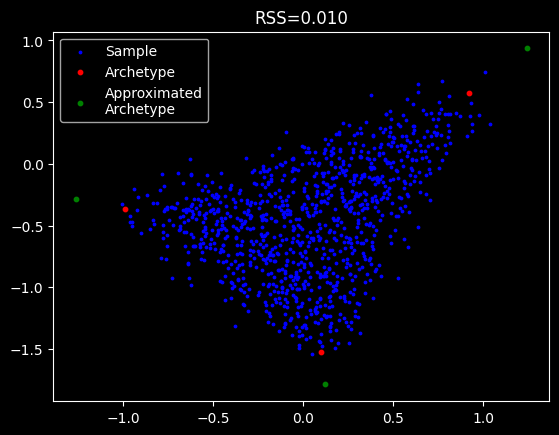

In [4]:
AA_object = pt.AA(n_archetypes=3, delta=0.25)
AA_object.fit(X)
Z_hat = AA_object.Z

plt.scatter(x=X[:, 0], y=X[:, 1], s=3, c="blue", label="Sample")
plt.scatter(x=Z[:, 0], y=Z[:, 1], s=10, c="red", label="Archetype")
plt.scatter(x=Z_hat[:, 0], y=Z_hat[:, 1], s=10, c="green", label="Approximated\nArchetype")
plt.title(f"RSS={AA_object.RSS:.3f}")
plt.legend()
plt.show()